# 🧠 05. Treinamento do Modelo (Arquitetura Modular)

## 🛠️  Imports e Configurações

### Pacotes 

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from src.tools import load_config, avaliar_modelo, registrar_metricas, excluir_colunas_modelo


### Configurações gerais

In [3]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

DATA_PATH = '../data/processed/dados_com_features.csv' 
# Caminho do arquivo processado gerado no Notebook 04
DATA_PROCESS = '../data/processed/dados_prontos_para_treino.pkl'
PATH_MODEL = '../models'
DATA_MODEL = '../models/model_final.pkl'


In [4]:
#🚩
config = load_config()
SPLIT_DATE = config['dates']['split_date']
EXCLUIR_COLUNA_MODELO = config['excluir_colunas_modelo']
print(f"data split: {SPLIT_DATE}") 
print(f'Colunas a serem excluidas: {EXCLUIR_COLUNA_MODELO}')


data split: 2017-10-01
Colunas a serem excluidas: ['date', 'sales', 'id', 'sales_log', 'day_name', 'holiday_name', 'year']


## ⛁ Carregando base

In [5]:
print(f"⏳ Carregando dados processados de: {DATA_PROCESS}")

with open(DATA_PROCESS, 'rb') as f:
    dados = pickle.load(f)

# O Pickle do NB 04 já traz tudo separado e tratado!
X_train_log = dados['X_train']    
y_train_log = dados['y_train']    
X_val_log = dados['X_val']       
y_val_log = dados['y_val']      

#🚩
X_train_log = excluir_colunas_modelo(X_train_log, EXCLUIR_COLUNA_MODELO)
y_train_log = excluir_colunas_modelo(y_train_log, EXCLUIR_COLUNA_MODELO)
X_val_log = excluir_colunas_modelo(X_val_log, EXCLUIR_COLUNA_MODELO)
y_val_log = excluir_colunas_modelo(y_val_log, EXCLUIR_COLUNA_MODELO)


print(f"✅ Dados carregados com sucesso!")
print(f"Treino X: {X_train_log.shape} | y: {y_train_log.shape}")
print(f"Validação X: {X_val_log.shape} | y: {y_val_log.shape}")

# Verificação de Sanidade (Para você ficar tranquilo sobre o Log)
print(f"\n--- Auditoria Final Pré-Treino ---")
print(f"Max y_train: {y_train_log.max():.4f}")
print(f"Média y_train: {y_train_log.mean():.4f}")

# Verificação de Sanidade (Para você ficar tranquilo sobre o Log)
print(f"\n--- Auditoria Final Pré-Treino ---")
print(f"Colunas treino: {X_train_log.columns}")
print(f"Colunas valida: {X_val_log.columns}")


⏳ Carregando dados processados de: ../data/processed/dados_prontos_para_treino.pkl


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/dados_prontos_para_treino.pkl'

## 🏋️‍♂️ Treinando o modelo

In [ ]:
X_train_log.columns

Index(['is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'store', 'item', 'month', 'day', 'day_of_week',
       'day_of_year'],
      dtype='object')

In [ ]:
print("\n🔥 Iniciando treinamento do RandomForest")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,       
    min_samples_leaf=4,  
    random_state=42,
    n_jobs=-1,  # 4 núcleos é mais estável que -1 no Windows p/ dados médios
    verbose=1
)

rf.fit(X_train_log, y_train_log)
print(f"✅ Modelo treinado! {rf.feature_names_in_}")



🔥 Iniciando treinamento do RandomForest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.1min


✅ Modelo treinado! ['is_weekend' 'is_payday' 'is_holiday' 'days_until_holiday' 'month_sin'
 'month_cos' 'day_of_week_sin' 'day_of_week_cos' 'day_of_year_sin'
 'day_of_year_cos' 'lag_1' 'lag_2' 'lag_3' 'lag_7' 'lag_14' 'lag_21'
 'lag_28' 'lag_91' 'rolling_mean_7' 'rolling_std_7' 'rolling_mean_28'
 'rolling_std_28' 'rolling_mean_91' 'rolling_std_91' 'store' 'item'
 'month' 'day' 'day_of_week' 'day_of_year']


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 11.7min finished


In [ ]:
# Previsão
preds = rf.predict(X_val_log)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.1s finished


In [ ]:
#🚩
# >>>Avaliar modelo e registrar métricas para comparar no final 

# Avaliar modelo
metrics = avaliar_modelo(y_val_log, preds, nome_modelo="Random Forest - Validação")

# Registrar metrica
registrar_metricas(
    modelo_nome="RandomForestRegressor",
    mae=metrics['mae'],
    rmse=metrics['rmse'],
    wape=metrics['wape'],
    mape=metrics.get('mape', 0), # use get caso não tenha calculado mape antes
    r2=metrics['r2'], 
    notebook="05_train_model.ipynb",
    etapa="treinamento"
)

--- Performance: RandomForestRegressor ---
MAE:  6.70 (Erro médio em unidades)
RMSE: 8.72 (Penaliza erros grandes)
WAPE: 9.84% (Erro percentual ponderado)
MAPE: 11.46% (Erro médio absoluto)
R²:   0.9353 (Aderência/Variância explicada)
------------------------------
✅ Métricas registradas com sucesso em: c:\Users\Sergio\Desktop\_ESTUDO\_portifolio_full\retail-demand-forecasting\data\metrics_history.csv


In [ ]:
X_val_log.columns

Index(['is_weekend', 'is_payday', 'is_holiday', 'days_until_holiday',
       'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_3',
       'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_91', 'rolling_mean_7',
       'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_91',
       'rolling_std_91', 'store', 'item', 'month', 'day', 'day_of_week',
       'day_of_year'],
      dtype='object')

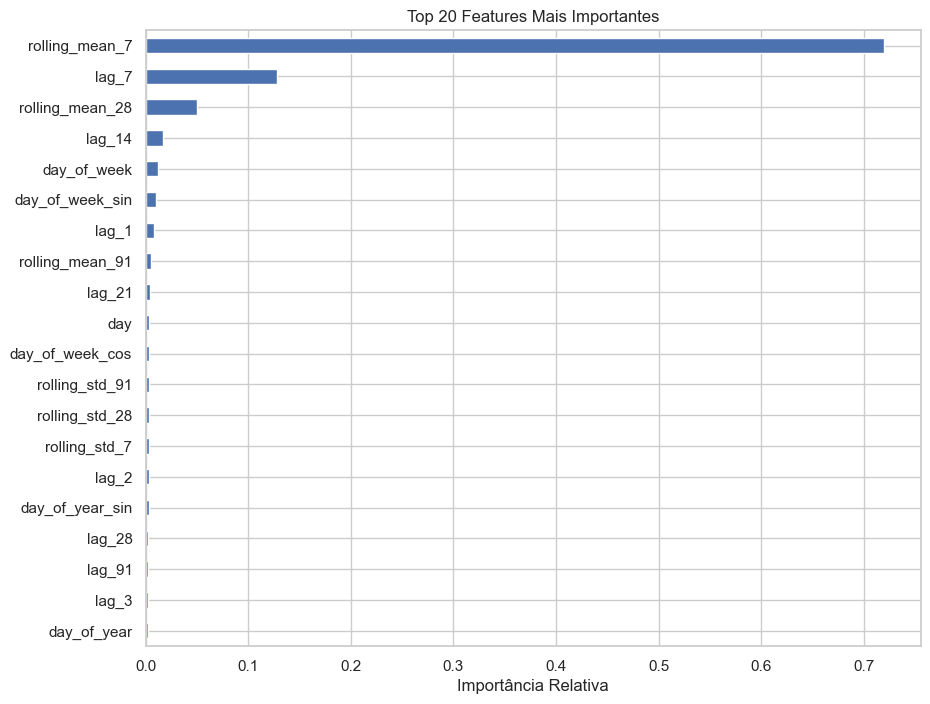

In [ ]:
features = X_val_log.columns
feat_importances = pd.Series(rf.feature_importances_, index=features)

# rf.feature_importances_

plt.figure(figsize=(10, 8))
feat_importances.nlargest(20).sort_values().plot(kind='barh')
plt.title('Top 20 Features Mais Importantes')
plt.xlabel('Importância Relativa')
plt.show()


 📝 Comentário

Análise de Importância de Variáveis (Feature Importance):

O gráfico confirma o sucesso da etapa de Feature Engineering ao transformar um dataset transacional em uma série temporal supervisionada eficaz.

Dominância de Autocorrelação: As variáveis de Lag (atrasos temporais) ocupam o topo do ranking. O destaque para lag_7, lag_14 e lag_28 comprova uma forte autocorrelação semanal e mensal. O modelo aprendeu a olhar para o passado histórico para projetar o futuro.

Tendência vs. Ruído: A alta importância da rolling_mean_7 sugere que o modelo utiliza a média da semana para suavizar o ruído diário (lag_1), garantindo previsões mais robustas.

Impacto no Modelo: A ausência de variáveis estáticas (como ID do item) no topo do ranking indica que o comportamento temporal (quanto vendeu) é um sinal muito mais forte do que a identidade do produto (o que é o item) para a previsão de demanda.

## 💾 4. Salvando o Arquivo

In [ ]:
os.makedirs(PATH_MODEL, exist_ok=True)
joblib.dump(rf, DATA_MODEL)
print(f"\n💾 Modelo salvo com sucesso em: {DATA_MODEL}")



💾 Modelo salvo com sucesso em: ../models/model_final.pkl
